# Weather Forecasting Machine Learning Project
Notebook created by: Ashlynn Blanshan

### importing the weather data set

In [1]:
import pandas as pd

df = pd.read_csv("hf://datasets/Katherinetian/weather_data_NC/weather_data.csv")

df.head()

,dt,main.temp,main.feels_like,main.pressure,main.humidity,main.temp_min,main.temp_max,wind.speed,wind.deg,wind.gust,...,longitude,date,rain.1h,weather_id,weather_main,weather_description,weather_icon,city,snow.1h,rain.3h
0,1679198400,281.21,279.60,1017,64,279.30,283.01,2.60,309,7.25,...,-78.639099,2023-03-19,NaN,804,Clouds,overcast clouds,04n,"Raleigh,NC,US",NaN,NaN
1,1679202000,281.01,281.01,1016,50,278.29,282.96,0.00,0,NaN,...,-78.639099,2023-03-19,NaN,803,Clouds,broken clouds,04n,"Raleigh,NC,US",NaN,NaN
2,1679205600,280.25,279.44,1015,49,277.93,281.96,1.54,310,NaN,...,-78.639099,2023-03-19,NaN,803,Clouds,broken clouds,04n,"Raleigh,NC,US",NaN,NaN
3,1679209200,280.69,279.01,1016,45,278.26,281.96,2.57,0,NaN,...,-78.639099,2023-03-19,NaN,803,Clouds,broken clouds,04n,"Raleigh,NC,US",NaN,NaN
4,1679212800,280.03,278.92,1016,45,277.71,281.96,1.79,38,4.02,...,-78.639099,2023-03-19,NaN,803,Clouds,broken clouds,04n,"Raleigh,NC,US",NaN,NaN


Here we have the dataset, since we have null values we must find ways to deal with the missing values.

In [2]:
print(df.isna().sum()) 

dt                         0
main.temp                  0
main.feels_like            0
main.pressure              0
main.humidity              0
main.temp_min              0
main.temp_max              0
wind.speed                 0
wind.deg                   0
wind.gust              49237
clouds.all                 0
latitude                   0
longitude                  0
date                       0
rain.1h                74873
weather_id                 0
weather_main               0
weather_description        0
weather_icon               0
city                       0
snow.1h                78614
rain.3h                78622
dtype: int64


## Data Cleaning

#### Missing Values
Since wind gust, rain.1h, snow.1h, and rain.3h have majority of missing values, I think it is best we drop these columns in its entirety instead of using imputation techniques.

I am also dropping 'dt' because it is irrelevant and I want to end up using the date-time as the index.

In [3]:
df = df.drop(columns=["wind.gust", "rain.1h", "snow.1h", "rain.3h", "dt"], errors='ignore')
df.head()

,main.temp,main.feels_like,main.pressure,main.humidity,main.temp_min,main.temp_max,wind.speed,wind.deg,clouds.all,latitude,longitude,date,weather_id,weather_main,weather_description,weather_icon,city
0,281.21,279.60,1017,64,279.30,283.01,2.60,309,94,35.780398,-78.639099,2023-03-19,804,Clouds,overcast clouds,04n,"Raleigh,NC,US"
1,281.01,281.01,1016,50,278.29,282.96,0.00,0,75,35.780398,-78.639099,2023-03-19,803,Clouds,broken clouds,04n,"Raleigh,NC,US"
2,280.25,279.44,1015,49,277.93,281.96,1.54,310,75,35.780398,-78.639099,2023-03-19,803,Clouds,broken clouds,04n,"Raleigh,NC,US"
3,280.69,279.01,1016,45,278.26,281.96,2.57,0,75,35.780398,-78.639099,2023-03-19,803,Clouds,broken clouds,04n,"Raleigh,NC,US"
4,280.03,278.92,1016,45,277.71,281.96,1.79,38,75,35.780398,-78.639099,2023-03-19,803,Clouds,broken clouds,04n,"Raleigh,NC,US"


In [4]:
# since we want to predict temperature using time-series analysis, it will be beneficial
# to convert the date column to a pandas date-time data type
print(df.dtypes)


main.temp              float64
main.feels_like        float64
main.pressure            int64
main.humidity            int64
main.temp_min          float64
main.temp_max          float64
wind.speed             float64
wind.deg                 int64
clouds.all               int64
latitude               float64
longitude              float64
date                    object
weather_id               int64
weather_main            object
weather_description     object
weather_icon            object
city                    object
dtype: object


In [5]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
print(df.dtypes)

main.temp                     float64
main.feels_like               float64
main.pressure                   int64
main.humidity                   int64
main.temp_min                 float64
main.temp_max                 float64
wind.speed                    float64
wind.deg                        int64
clouds.all                      int64
latitude                      float64
longitude                     float64
date                   datetime64[ns]
weather_id                      int64
weather_main                   object
weather_description            object
weather_icon                   object
city                           object
dtype: object


#### Plotting the Data

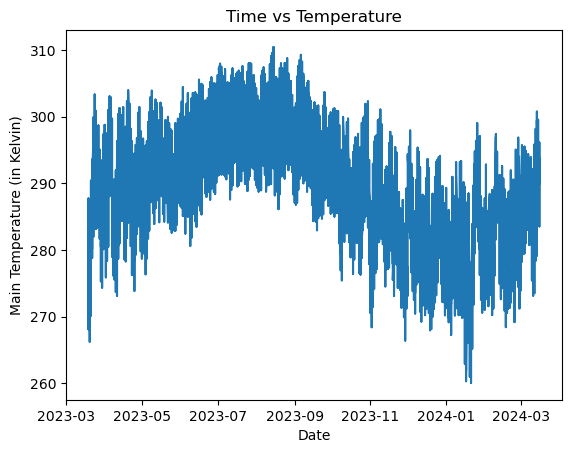

In [6]:
import matplotlib.pyplot as plt

x = df["date"]
y = df["main.temp"]

plt.plot(x, y)
plt.xlabel("Date")
plt.ylabel("Main Temperature (in Kelvin)")
plt.title("Time vs Temperature")
plt.show()

#### Correlation Matrix

<Axes: >

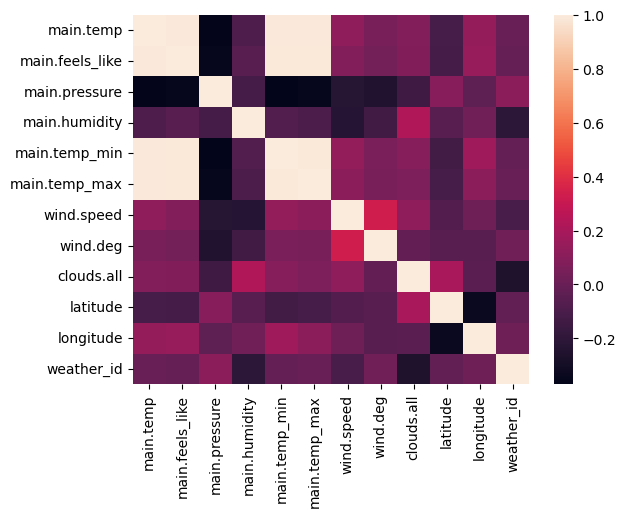

In [7]:
import seaborn as sns

df_num = df.drop(columns=['date', 'weather_main' , 'weather_description' , 'weather_icon' , 'city'])
corr_matrix = df_num.corr(numeric_only=True)

sns.heatmap(data=corr_matrix)

#### Dropping Irrelevant Columns
Looking at this correlation matrix, I realized that we should drop the "main.feels_like", "main.temp_min" and "main.temp_max" columns since they are basically derived from the temperature and we are trying to make a model that accurately predicts the temperature.

In [8]:
df = df.drop(columns=['main.feels_like' , 'main.temp_min', 'main.temp_max'])
df.head()

,main.temp,main.pressure,main.humidity,wind.speed,wind.deg,clouds.all,latitude,longitude,date,weather_id,weather_main,weather_description,weather_icon,city
0,281.21,1017,64,2.60,309,94,35.780398,-78.639099,2023-03-19,804,Clouds,overcast clouds,04n,"Raleigh,NC,US"
17484,283.21,1019,46,0.89,291,64,35.108493,-77.044114,2023-03-19,803,Clouds,broken clouds,04d,"New Bern,NC,US"
17483,282.06,1019,50,0.89,285,84,35.108493,-77.044114,2023-03-19,803,Clouds,broken clouds,04d,"New Bern,NC,US"
17482,281.32,1020,59,4.59,346,92,35.108493,-77.044114,2023-03-19,804,Clouds,overcast clouds,04d,"New Bern,NC,US"
17480,280.91,1018,60,4.18,347,96,35.108493,-77.044114,2023-03-19,804,Clouds,overcast clouds,04d,"New Bern,NC,US"


In [9]:
weather = df["weather_main"].unique()

for i in weather:
    count = (df["weather_main"] == i).sum()
    print("the number of entries for " , i , " is ", count)

the number of entries for  Clouds  is  43628
the number of entries for  Clear  is  27959
the number of entries for  Rain  is  3379
the number of entries for  Smoke  is  122
the number of entries for  Fog  is  325
the number of entries for  Mist  is  2046
the number of entries for  Drizzle  is  341
the number of entries for  Thunderstorm  is  317
the number of entries for  Haze  is  496
the number of entries for  Snow  is  10
the number of entries for  Squall  is  1


#### Encoding
I am going to get rid of irrelevant weather types based upon their value count into "other" so that we still include them since we are dealing with time-series data, and to prevent noise. Then I am going to encode the variable into numerical variables using pandas dummy variable function.

In [10]:
counts = df['weather_main'].value_counts()
irr = counts[counts < 500].index

df['weather_main'] = df['weather_main'].replace(irr, 'Other')

df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

df.head()

,main.temp,main.pressure,main.humidity,wind.speed,wind.deg,clouds.all,latitude,longitude,date,weather_id,weather_description,weather_icon,city,weather_main_Clouds,weather_main_Mist,weather_main_Other,weather_main_Rain
0,281.21,1017,64,2.60,309,94,35.780398,-78.639099,2023-03-19,804,overcast clouds,04n,"Raleigh,NC,US",True,False,False,False
17484,283.21,1019,46,0.89,291,64,35.108493,-77.044114,2023-03-19,803,broken clouds,04d,"New Bern,NC,US",True,False,False,False
17483,282.06,1019,50,0.89,285,84,35.108493,-77.044114,2023-03-19,803,broken clouds,04d,"New Bern,NC,US",True,False,False,False
17482,281.32,1020,59,4.59,346,92,35.108493,-77.044114,2023-03-19,804,overcast clouds,04d,"New Bern,NC,US",True,False,False,False
17480,280.91,1018,60,4.18,347,96,35.108493,-77.044114,2023-03-19,804,overcast clouds,04d,"New Bern,NC,US",True,False,False,False


#### Dropping More Columns

In [11]:
df = df.drop(columns=['weather_description' , 'weather_id', 'weather_description', 'weather_icon'])
df.head()

,main.temp,main.pressure,main.humidity,wind.speed,wind.deg,clouds.all,latitude,longitude,date,city,weather_main_Clouds,weather_main_Mist,weather_main_Other,weather_main_Rain
0,281.21,1017,64,2.60,309,94,35.780398,-78.639099,2023-03-19,"Raleigh,NC,US",True,False,False,False
17484,283.21,1019,46,0.89,291,64,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False
17483,282.06,1019,50,0.89,285,84,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False
17482,281.32,1020,59,4.59,346,92,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False
17480,280.91,1018,60,4.18,347,96,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False


## Feature Engineering
Since we are using time series data, it is important to create features in relation to time that can help predict the temperature. There a many techniques out there such as lag features, rolling features, time features, etc. 

In [ ]:
# since we will be getting rid of the date time column for ML, it is good to make time based features.

df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['day'] = df['date'].dt.day

df.head()

,main.temp,main.pressure,main.humidity,wind.speed,wind.deg,clouds.all,latitude,longitude,date,city,weather_main_Clouds,weather_main_Mist,weather_main_Other,weather_main_Rain,year,quarter,month,week,day
0,281.21,1017,64,2.60,309,94,35.780398,-78.639099,2023-03-19,"Raleigh,NC,US",True,False,False,False,2023,1,3,11,19
17484,283.21,1019,46,0.89,291,64,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False,2023,1,3,11,19
17483,282.06,1019,50,0.89,285,84,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False,2023,1,3,11,19
17482,281.32,1020,59,4.59,346,92,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False,2023,1,3,11,19
17480,280.91,1018,60,4.18,347,96,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",True,False,False,False,2023,1,3,11,19


In [ ]:
# from researching time series forecasting, cyclical encoding is great with time since time in nature is cyclical
import numpy as np

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [ ]:
# lag features, another good feature engineering method for time series forecasting

df['lag_1'] = df['main.temp'].shift(1)
df['lag_2'] = df['main.temp'].shift(2)
df['lag_7'] = df['main.temp'].shift(7)

df.head()

,main.temp,main.pressure,main.humidity,wind.speed,wind.deg,clouds.all,latitude,longitude,date,city,...,month,week,day,day_sin,day_cos,month_sin,month_cos,lag_1,lag_2,lag_7
0,281.21,1017,64,2.60,309,94,35.780398,-78.639099,2023-03-19,"Raleigh,NC,US",...,3,11,19,-0.974928,-0.222521,1.0,6.123234e-17,NaN,NaN,NaN
17484,283.21,1019,46,0.89,291,64,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",...,3,11,19,-0.974928,-0.222521,1.0,6.123234e-17,281.21,NaN,NaN
17483,282.06,1019,50,0.89,285,84,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",...,3,11,19,-0.974928,-0.222521,1.0,6.123234e-17,283.21,281.21,NaN
17482,281.32,1020,59,4.59,346,92,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",...,3,11,19,-0.974928,-0.222521,1.0,6.123234e-17,282.06,283.21,NaN
17480,280.91,1018,60,4.18,347,96,35.108493,-77.044114,2023-03-19,"New Bern,NC,US",...,3,11,19,-0.974928,-0.222521,1.0,6.123234e-17,281.32,282.06,NaN


In [15]:
city_names = df["city"].unique()

for i in city_names:
    count = (df["city"] == i).sum()
    print("the number of entries for " , i , " is ", count)

the number of entries for  Raleigh,NC,US  is  8736
the number of entries for  New Bern,NC,US  is  8736
the number of entries for  Wilmington,NC,US  is  8736
the number of entries for  Asheville,NC,US  is  8736
the number of entries for  Winnabow,NC,USChapel Hill,NC,US  is  8736
the number of entries for  Greensboro,NC,US  is  8736
the number of entries for  Charlotte,NC,US  is  8736
the number of entries for  Durham,NC,US  is  8736
the number of entries for  Greenville,NC,US  is  8736


#### Narrowing it down to a city

I am thinking for now is to focus on one city, I am going to pick Asheville to create a baseline prediction model.

In [16]:
df_asheville = df[df["city"] == 'Asheville,NC,US']
df_asheville.head()

,main.temp,main.pressure,main.humidity,wind.speed,wind.deg,clouds.all,latitude,longitude,date,city,...,month,week,day,day_sin,day_cos,month_sin,month_cos,lag_1,lag_2,lag_7
8739,271.83,1017,62,5.14,340,20,35.60095,-82.554016,2023-03-19,"Asheville,NC,US",...,3,11,19,-0.974928,-0.222521,1.0,6.123234e-17,285.23,284.77,284.08
8740,271.15,1017,58,7.72,340,0,35.60095,-82.554016,2023-03-19,"Asheville,NC,US",...,3,11,19,-0.974928,-0.222521,1.0,6.123234e-17,271.83,285.23,284.84
8741,270.07,1017,58,6.17,340,0,35.60095,-82.554016,2023-03-19,"Asheville,NC,US",...,3,11,19,-0.974928,-0.222521,1.0,6.123234e-17,271.15,271.83,285.71
8742,269.24,1018,61,4.63,350,0,35.60095,-82.554016,2023-03-19,"Asheville,NC,US",...,3,11,19,-0.974928,-0.222521,1.0,6.123234e-17,270.07,271.15,283.76
8743,268.51,1019,64,7.20,340,0,35.60095,-82.554016,2023-03-19,"Asheville,NC,US",...,3,11,19,-0.974928,-0.222521,1.0,6.123234e-17,269.24,270.07,286.63


In [19]:
#Train/Test split

split = int(len(df_asheville) * 0.8)

train = df_asheville.iloc[:split]
test = df_asheville.iloc[split:]

X_train = train.drop(columns=['main.temp', 'date', 'city'])
y_train = train['main.temp']

X_test = test.drop(columns=['main.temp', 'date', 'city'])
y_test = test['main.temp']

In [20]:
# linear regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred = lin_reg.predict(X_test)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

MAE: 2.4547
RMSE: 3.2375
R^2: 0.7670


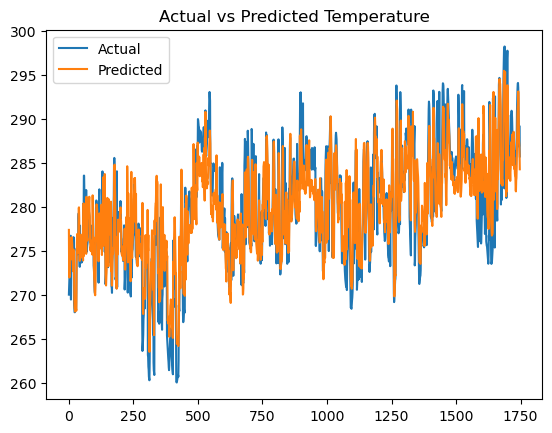

In [36]:

plt.figure()

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.legend()
plt.title('Actual vs Predicted Temperature')
plt.show()

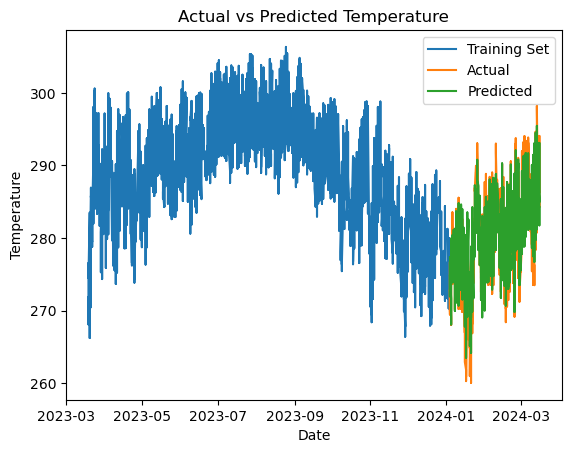

In [37]:

plt.figure()

# Training data
plt.plot(train['date'], y_train, label='Training Set')

# Actual test values
plt.plot(test['date'], y_test.values, label='Actual')

# Predicted values
plt.plot(test['date'], y_pred, label='Predicted')

plt.legend()
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')

plt.show()

Overall pretty good baseline linear regression model, the MAE and RMSE suggest that the model predictions is off by a few kelvin which is pretty accurate. Since we are using linear regression it may good to test out either ridge or lasso regression before going to more advanced models such as tree based regressors (XGBoost is a good example) or LSTM's.

In [39]:
from sklearn.linear_model import Lasso

lin_reg_lasso = Lasso()
lin_reg_lasso.fit(X_train, y_train)

Lasso()

In [40]:
y_pred = lin_reg_lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

MAE: 2.2511
RMSE: 3.2161
R^2: 0.7701


Performed Lasso, got simliar results

In [41]:
from sklearn.linear_model import Ridge

lin_reg_ridge = Ridge()
lin_reg_ridge.fit(X_train, y_train)

Ridge()

In [42]:
y_pred = lin_reg_ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

MAE: 2.4547
RMSE: 3.2365
R^2: 0.7672


Here I performed Ridge Regression, got simliar results, proof that while linear regression is a good baseline, it is important to branch out to more elaborate models.